# ResNet18 on Food-101

Fine-tuning strategies:
1. Linear Probing
2. BatchNorm Tuning
3. Adapter Tuning
4. LoRA
5. Full Fine-tuning

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models import resnet18, ResNet18_Weights
from pathlib import Path
from PIL import Image
import time
import json
import math
import matplotlib.pyplot as plt
from contextlib import nullcontext

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Data Loading

In [2]:
import kagglehub
path = kagglehub.dataset_download("dansbecker/food-101")
base_path = Path(path) / "food-101" / "food-101"
print(f"Dataset path: {base_path}")

/home/yuewang/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset path: /home/yuewang/.cache/kagglehub/datasets/dansbecker/food-101/versions/1/food-101/food-101


In [3]:
class Food101Dataset(Dataset):
    def __init__(self, root, split_file, transform=None, class_to_idx=None):
        self.root = Path(root)
        self.transform = transform

        with open(split_file, "r", encoding="utf-8") as f:
            self.samples = [line.strip() for line in f if line.strip()]

        if class_to_idx is None:
            classes = sorted({x.split('/')[0] for x in self.samples})
            self.class_to_idx = {c: i for i, c in enumerate(classes)}
        else:
            self.class_to_idx = dict(class_to_idx)

        self.classes = sorted(self.class_to_idx, key=self.class_to_idx.get)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        label_name = item.split('/')[0]
        img_path = self.root / "images" / f"{item}.jpg"
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        label = self.class_to_idx[label_name]
        return img, label

In [4]:
weights = ResNet18_Weights.IMAGENET1K_V1
transform = weights.transforms()

full_train_dataset = Food101Dataset(
    root=base_path,
    split_file=base_path / "meta" / "train.txt",
    transform=transform,
)

test_dataset = Food101Dataset(
    root=base_path,
    split_file=base_path / "meta" / "test.txt",
    transform=transform,
    class_to_idx=full_train_dataset.class_to_idx,
)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True,  num_workers=8, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=8, pin_memory=True, persistent_workers=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 60600 | Val: 15150 | Test: 25250


## Training & Evaluation Utilities

In [5]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    epochs=30,
    patience=3,
    save_path="best_model.pth",
):
    best_val_loss = float("inf")
    counter = 0
    history = {"train_loss": [], "val_loss": [], "val_acc": [], "epoch_time": []}

    use_amp = device.type == "cuda"
    scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

    total_start = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        model.train()
        train_loss = 0.0
        for imgs, labels in train_loader:
            imgs   = imgs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            amp_ctx = torch.autocast(device_type="cuda", dtype=torch.float16) if use_amp else nullcontext()
            with amp_ctx:
                outputs = model(imgs)
                loss = criterion(outputs, labels)
            if use_amp:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs   = imgs.to(device)
                labels = labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                preds = outputs.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total   += labels.size(0)
        val_loss /= len(val_loader)
        val_acc = correct / total

        epoch_time = time.time() - epoch_start
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Time: {epoch_time:.2f}s")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), save_path)
            print("  Best model saved")
        else:
            counter += 1
            print(f"  No improvement ({counter}/{patience})")
            if counter >= patience:
                print("  Early stopping triggered")
                break

    total_time = time.time() - total_start
    print(f"\nTotal training time: {total_time:.2f}s")
    history["total_time"] = total_time
    history["trainable_params"] = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return history


def evaluate_metrics(model, loader, criterion, device):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss    += loss.item() * labels.size(0)
            total_correct += (outputs.argmax(dim=1) == labels).sum().item()
            total_seen    += labels.size(0)
    return {"loss": total_loss / max(total_seen, 1), "acc": total_correct / max(total_seen, 1)}


def plot_history(history, title_prefix=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train Loss")
    axes[0].plot(history["val_loss"],   label="Val Loss")
    axes[0].set_title(f"{title_prefix} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid()
    axes[1].plot(history["val_acc"], label="Val Accuracy")
    axes[1].set_title(f"{title_prefix} Validation Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid()
    plt.tight_layout()
    plt.show()

## Strategy 1: Linear Probing

In [6]:
model = resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 101)

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

Trainable params: 51,813


Epoch 1/30 | Train Loss: 3.1076 | Val Loss: 2.4070 | Val Acc: 0.4532 | Time: 30.04s
  Best model saved
Epoch 2/30 | Train Loss: 2.1725 | Val Loss: 2.1261 | Val Acc: 0.4890 | Time: 28.13s
  Best model saved
Epoch 3/30 | Train Loss: 1.9640 | Val Loss: 2.0223 | Val Acc: 0.5079 | Time: 28.07s
  Best model saved
Epoch 4/30 | Train Loss: 1.8586 | Val Loss: 1.9629 | Val Acc: 0.5181 | Time: 28.81s
  Best model saved
Epoch 5/30 | Train Loss: 1.7901 | Val Loss: 1.9418 | Val Acc: 0.5207 | Time: 28.67s
  Best model saved
Epoch 6/30 | Train Loss: 1.7411 | Val Loss: 1.9109 | Val Acc: 0.5277 | Time: 28.47s
  Best model saved
Epoch 7/30 | Train Loss: 1.7088 | Val Loss: 1.9080 | Val Acc: 0.5280 | Time: 28.73s
  Best model saved
Epoch 8/30 | Train Loss: 1.6771 | Val Loss: 1.8973 | Val Acc: 0.5306 | Time: 28.68s
  Best model saved
Epoch 9/30 | Train Loss: 1.6534 | Val Loss: 1.8893 | Val Acc: 0.5327 | Time: 28.19s
  Best model saved
Epoch 10/30 | Train Loss: 1.6306 | Val Loss: 1.9049 | Val Acc: 0.5275 | T

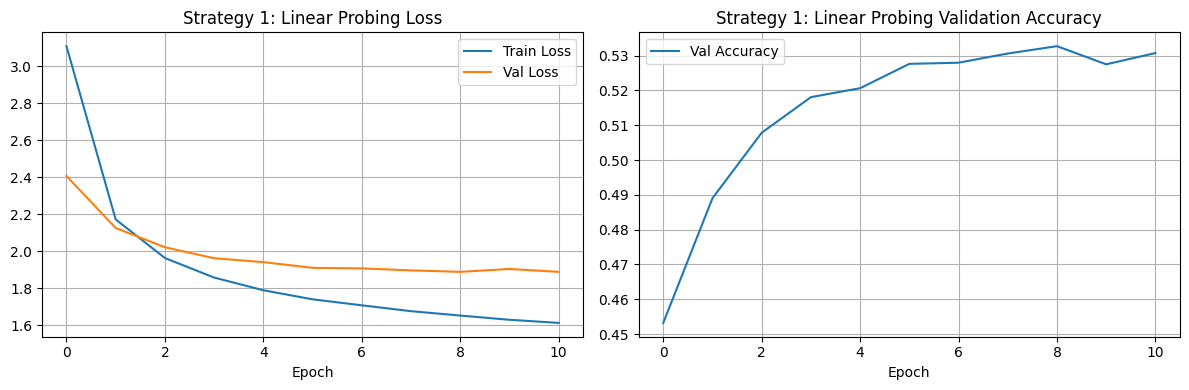

In [7]:
history_s1 = train_model(
    model, train_loader, val_loader, criterion, optimizer, device,
    epochs=30, patience=2, save_path="best_s1_linear_probe.pth",
)

with open("history_s1_linear_probe.json", "w") as f:
    json.dump(history_s1, f)

#1.8gb vram

model.load_state_dict(torch.load("best_s1_linear_probe.pth", map_location=device))
test_metrics_s1 = evaluate_metrics(model, test_loader, criterion, device)
print(f"Test Loss: {test_metrics_s1['loss']:.4f} | Test Acc: {test_metrics_s1['acc']:.4f}")
plot_history(history_s1, "Strategy 1: Linear Probing")

## Strategy 2: BatchNorm Tuning

In [6]:
model = resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 101)

for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True
for m in model.modules():
    if isinstance(m, nn.BatchNorm2d):
        if m.weight is not None:
            m.weight.requires_grad = True
        if m.bias is not None:
            m.bias.requires_grad = True

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

Trainable params: 61,413


Epoch 1/30 | Train Loss: 2.6209 | Val Loss: 1.8262 | Val Acc: 0.5451 | Time: 34.45s
  Best model saved
Epoch 2/30 | Train Loss: 1.6543 | Val Loss: 1.6122 | Val Acc: 0.5917 | Time: 29.19s
  Best model saved
Epoch 3/30 | Train Loss: 1.4731 | Val Loss: 1.5168 | Val Acc: 0.6145 | Time: 28.84s
  Best model saved
Epoch 4/30 | Train Loss: 1.3788 | Val Loss: 1.4854 | Val Acc: 0.6230 | Time: 29.50s
  Best model saved
Epoch 5/30 | Train Loss: 1.3135 | Val Loss: 1.4721 | Val Acc: 0.6235 | Time: 28.93s
  Best model saved
Epoch 6/30 | Train Loss: 1.2684 | Val Loss: 1.4452 | Val Acc: 0.6301 | Time: 28.77s
  Best model saved
Epoch 7/30 | Train Loss: 1.2253 | Val Loss: 1.4485 | Val Acc: 0.6294 | Time: 29.10s
  No improvement (1/2)
Epoch 8/30 | Train Loss: 1.1920 | Val Loss: 1.4382 | Val Acc: 0.6335 | Time: 29.06s
  Best model saved
Epoch 9/30 | Train Loss: 1.1691 | Val Loss: 1.4313 | Val Acc: 0.6330 | Time: 28.91s
  Best model saved
Epoch 10/30 | Train Loss: 1.1414 | Val Loss: 1.4217 | Val Acc: 0.6410

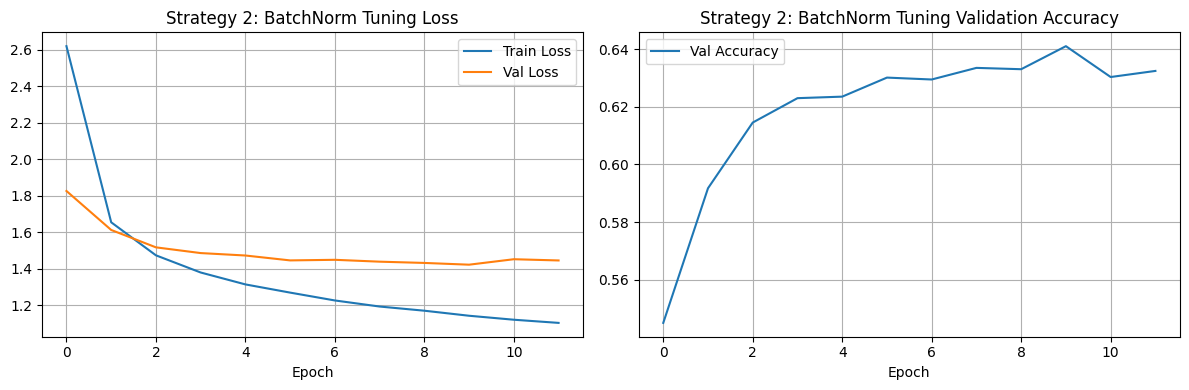

In [7]:
history_s2 = train_model(
    model, train_loader, val_loader, criterion, optimizer, device,
    epochs=30, patience=2, save_path="best_s2_batchnorm.pth",
)

with open("history_s2_batchnorm.json", "w") as f:
    json.dump(history_s2, f)

#4gb vram

model.load_state_dict(torch.load("best_s2_batchnorm.pth", map_location=device))
test_metrics_s2 = evaluate_metrics(model, test_loader, criterion, device)
print(f"Test Loss: {test_metrics_s2['loss']:.4f} | Test Acc: {test_metrics_s2['acc']:.4f}")
plot_history(history_s2, "Strategy 2: BatchNorm Tuning")

## Strategy 3: Adapter Tuning

In [6]:
class ConvAdapter(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.down = nn.Conv2d(channels, hidden, kernel_size=1, bias=False)
        self.act  = nn.ReLU(inplace=True)
        self.up   = nn.Conv2d(hidden, channels, kernel_size=1, bias=False)
        nn.init.zeros_(self.up.weight)

    def forward(self, x):
        return x + self.up(self.act(self.down(x)))


class ResNetBlockWithAdapter(nn.Module):
    def __init__(self, block, out_channels, reduction=16):
        super().__init__()
        self.block   = block
        self.adapter = ConvAdapter(out_channels, reduction=reduction)

    def forward(self, x):
        return self.adapter(self.block(x))


def inject_adapters(model, reduction=16):
    for layer_name in ["layer1", "layer2", "layer3", "layer4"]:
        layer = getattr(model, layer_name)
        for idx in range(len(layer)):
            block = layer[idx]
            ch = block.conv3.out_channels if hasattr(block, "conv3") else block.conv2.out_channels
            layer[idx] = ResNetBlockWithAdapter(block, ch, reduction=reduction)


model = resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 101)

inject_adapters(model, reduction=16)

for p in model.parameters():
    p.requires_grad = False
for name, p in model.named_parameters():
    if "adapter." in name or name.startswith("fc."):
        p.requires_grad = True

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

Trainable params: 138,853


Epoch 1/30 | Train Loss: 2.4829 | Val Loss: 1.7886 | Val Acc: 0.5420 | Time: 32.89s
  Best model saved
Epoch 2/30 | Train Loss: 1.5199 | Val Loss: 1.5400 | Val Acc: 0.6015 | Time: 29.10s
  Best model saved
Epoch 3/30 | Train Loss: 1.3066 | Val Loss: 1.4752 | Val Acc: 0.6251 | Time: 29.17s
  Best model saved
Epoch 4/30 | Train Loss: 1.1766 | Val Loss: 1.4507 | Val Acc: 0.6312 | Time: 28.93s
  Best model saved
Epoch 5/30 | Train Loss: 1.0831 | Val Loss: 1.4334 | Val Acc: 0.6352 | Time: 29.10s
  Best model saved
Epoch 6/30 | Train Loss: 1.0056 | Val Loss: 1.3803 | Val Acc: 0.6440 | Time: 29.17s
  Best model saved
Epoch 7/30 | Train Loss: 0.9435 | Val Loss: 1.3777 | Val Acc: 0.6481 | Time: 29.35s
  Best model saved
Epoch 8/30 | Train Loss: 0.8873 | Val Loss: 1.4164 | Val Acc: 0.6431 | Time: 29.13s
  No improvement (1/2)
Epoch 9/30 | Train Loss: 0.8399 | Val Loss: 1.4059 | Val Acc: 0.6428 | Time: 29.49s
  No improvement (2/2)
  Early stopping triggered

Total training time: 267.70s
Test Los

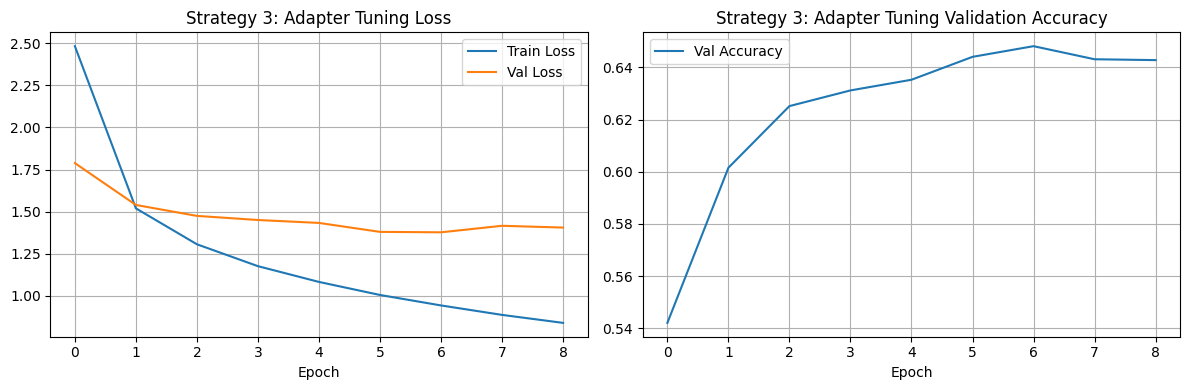

In [7]:
history_s3 = train_model(
    model, train_loader, val_loader, criterion, optimizer, device,
    epochs=30, patience=2, save_path="best_s3_adapter.pth",
)

with open("history_s3_adapter.json", "w") as f:
    json.dump(history_s3, f)

#2.3gb vram

model.load_state_dict(torch.load("best_s3_adapter.pth", map_location=device))
test_metrics_s3 = evaluate_metrics(model, test_loader, criterion, device)
print(f"Test Loss: {test_metrics_s3['loss']:.4f} | Test Acc: {test_metrics_s3['acc']:.4f}")
plot_history(history_s3, "Strategy 3: Adapter Tuning")

## Strategy 4: LoRA

In [6]:
class LoRAConv2d(nn.Module):
    def __init__(self, conv: nn.Conv2d, rank=4, alpha=8.0):
        super().__init__()
        self.conv    = conv
        self.rank    = rank
        self.alpha   = alpha
        self.scaling = alpha / rank

        for p in self.conv.parameters():
            p.requires_grad = False

        in_features = (conv.in_channels // conv.groups) * conv.kernel_size[0] * conv.kernel_size[1]
        self.lora_A = nn.Parameter(torch.zeros(conv.out_channels, rank))
        self.lora_B = nn.Parameter(torch.zeros(rank, in_features))

        nn.init.kaiming_uniform_(self.lora_B, a=math.sqrt(5))
        nn.init.zeros_(self.lora_A)

    def forward(self, x):
        base = self.conv(x)
        delta_w = (self.lora_A @ self.lora_B).view(
            self.conv.out_channels,
            self.conv.in_channels // self.conv.groups,
            self.conv.kernel_size[0],
            self.conv.kernel_size[1],
        )
        delta = F.conv2d(
            x, delta_w * self.scaling,
            bias=None,
            stride=self.conv.stride,
            padding=self.conv.padding,
            dilation=self.conv.dilation,
            groups=self.conv.groups,
        )
        return base + delta


def _inject_lora_conv(module, rank=4, alpha=8.0):
    for name, child in list(module.named_children()):
        if isinstance(child, nn.Conv2d):
            setattr(module, name, LoRAConv2d(child, rank=rank, alpha=alpha))
        else:
            _inject_lora_conv(child, rank=rank, alpha=alpha)


model = resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 101)

for layer_name in ["layer1", "layer2", "layer3", "layer4"]:
    _inject_lora_conv(getattr(model, layer_name), rank=4, alpha=8.0)

for p in model.parameters():
    p.requires_grad = False
for name, p in model.named_parameters():
    if "lora_A" in name or "lora_B" in name or name.startswith("fc."):
        p.requires_grad = True

model = model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=2e-3
)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

Trainable params: 194,661


In [ ]:
history_s4 = train_model(
    model, train_loader, val_loader, criterion, optimizer, device,
    epochs=30, patience=2, save_path="best_s4_lora.pth",
)

with open("history_s4_lora.json", "w") as f:
    json.dump(history_s4, f)

#4.5 gb vram

model.load_state_dict(torch.load("best_s4_lora.pth", map_location=device))
test_metrics_s4 = evaluate_metrics(model, test_loader, criterion, device)
print(f"Test Loss: {test_metrics_s4['loss']:.4f} | Test Acc: {test_metrics_s4['acc']:.4f}")
plot_history(history_s4, "Strategy 4: LoRA")

Epoch 1/30 | Train Loss: 2.2138 | Val Loss: 1.7255 | Val Acc: 0.5549 | Time: 41.25s
  Best model saved
Epoch 2/30 | Train Loss: 1.4308 | Val Loss: 1.6055 | Val Acc: 0.5879 | Time: 37.85s
  Best model saved
Epoch 3/30 | Train Loss: 1.2448 | Val Loss: 1.5054 | Val Acc: 0.6187 | Time: 37.74s
  Best model saved
Epoch 4/30 | Train Loss: 1.1298 | Val Loss: 1.5557 | Val Acc: 0.6039 | Time: 37.75s
  No improvement (1/2)
Epoch 5/30 | Train Loss: 1.0423 | Val Loss: 1.5842 | Val Acc: 0.6000 | Time: 38.08s
  No improvement (2/2)
  Early stopping triggered

Total training time: 193.31s


## Strategy 5: Full Fine-tuning

In [6]:
model = resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 101)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable:,}")

Trainable params: 11,228,325


Epoch 1/30 | Train Loss: 2.5399 | Val Loss: 1.6396 | Val Acc: 0.6157 | Time: 36.06s
  Best model saved
Epoch 2/30 | Train Loss: 1.2821 | Val Loss: 1.3096 | Val Acc: 0.6778 | Time: 32.68s
  Best model saved
Epoch 3/30 | Train Loss: 0.8261 | Val Loss: 1.2174 | Val Acc: 0.6906 | Time: 32.96s
  Best model saved
Epoch 4/30 | Train Loss: 0.4964 | Val Loss: 1.1875 | Val Acc: 0.6991 | Time: 33.06s
  Best model saved
Epoch 5/30 | Train Loss: 0.2501 | Val Loss: 1.1752 | Val Acc: 0.7040 | Time: 32.65s
  Best model saved
Epoch 6/30 | Train Loss: 0.1051 | Val Loss: 1.1673 | Val Acc: 0.7076 | Time: 32.83s
  Best model saved
Epoch 7/30 | Train Loss: 0.0420 | Val Loss: 1.1835 | Val Acc: 0.7084 | Time: 33.11s
  No improvement (1/2)
Epoch 8/30 | Train Loss: 0.0206 | Val Loss: 1.1876 | Val Acc: 0.7107 | Time: 32.69s
  No improvement (2/2)
  Early stopping triggered

Total training time: 267.18s
Test Loss: 0.9256 | Test Acc: 0.7574


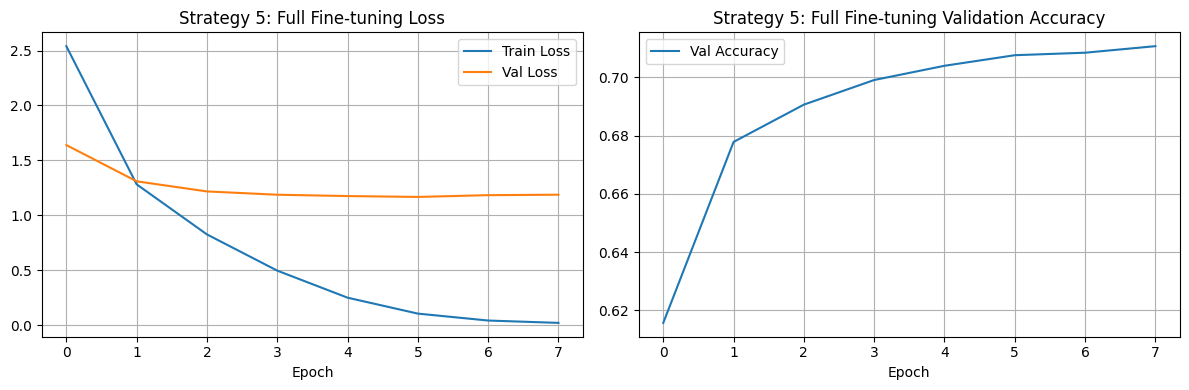

In [7]:
history_s5 = train_model(
    model, train_loader, val_loader, criterion, optimizer, device,
    epochs=30, patience=2, save_path="best_s5_full_finetune.pth",
)

with open("history_s5_full_finetune.json", "w") as f:
    json.dump(history_s5, f)

#5.7gb vram

model.load_state_dict(torch.load("best_s5_full_finetune.pth", map_location=device))
test_metrics_s5 = evaluate_metrics(model, test_loader, criterion, device)
print(f"Test Loss: {test_metrics_s5['loss']:.4f} | Test Acc: {test_metrics_s5['acc']:.4f}")
plot_history(history_s5, "Strategy 5: Full Fine-tuning")

## Results Summary

In [16]:
results = {
    "Linear Probing":   test_metrics_s1,
    "BatchNorm Tuning": test_metrics_s2,
    "Adapter Tuning":   test_metrics_s3,
    "LoRA":             test_metrics_s4,
    "Full Fine-tuning": test_metrics_s5,
}

print(f"{'Strategy':<22} {'Test Loss':>12} {'Test Acc':>10}")
print("-" * 46)
for name, m in results.items():
    print(f"{name:<22} {m['loss']:>12.4f} {m['acc']:>10.4f}")

Strategy                  Test Loss   Test Acc
----------------------------------------------
Linear Probing               1.6402     0.5755
BatchNorm Tuning             1.1689     0.6847
Adapter Tuning               1.1222     0.6922
LoRA                         1.2322     0.6705
Full Fine-tuning             0.9206     0.7553


## Strategy 6: Custom Model (Augmentation + Regularization)

Full fine-tuning with data augmentation (RandomResizedCrop, HorizontalFlip, ColorJitter), label smoothing (0.1), and weight decay (1e-4).

In [17]:
from torchvision import transforms as T

augment_transform = T.Compose([
    T.RandomResizedCrop(224, scale=(0.7, 1.0)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

aug_full = Food101Dataset(
    root=base_path,
    split_file=base_path / "meta" / "train.txt",
    transform=augment_transform,
)
aug_train, _ = random_split(
    aug_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(42),
)
aug_train_loader = DataLoader(aug_train, batch_size=256, shuffle=True,
                               num_workers=6, pin_memory=True, persistent_workers=True)

model_s6 = resnet18(weights=weights)
model_s6.fc = nn.Linear(model_s6.fc.in_features, 101)
model_s6 = model_s6.to(device)

criterion_s6 = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer_s6 = torch.optim.Adam(model_s6.parameters(), lr=1e-4, weight_decay=1e-4)

print(f"Trainable params: {sum(p.numel() for p in model_s6.parameters() if p.requires_grad):,}")

Trainable params: 11,228,325


Epoch 1/30 | Train Loss: 3.0541 | Val Loss: 2.3165 | Val Acc: 0.5793 | Time: 52.35s
  Best model saved


Epoch 2/30 | Train Loss: 2.1253 | Val Loss: 2.0155 | Val Acc: 0.6504 | Time: 52.44s
  Best model saved


Epoch 3/30 | Train Loss: 1.8723 | Val Loss: 1.8997 | Val Acc: 0.6812 | Time: 51.90s
  Best model saved


Epoch 4/30 | Train Loss: 1.7200 | Val Loss: 1.8421 | Val Acc: 0.7005 | Time: 52.00s
  Best model saved


Epoch 5/30 | Train Loss: 1.6080 | Val Loss: 1.8194 | Val Acc: 0.7030 | Time: 51.97s
  Best model saved


...

Epoch 9/30 | Train Loss: 1.3141 | Val Loss: 1.7723 | Val Acc: 0.7234 | Time: 52.45s
  Best model saved


Epoch 10/30 | Train Loss: 1.2636 | Val Loss: 1.8073 | Val Acc: 0.7091 | Time: 52.02s
  No improvement (1/3)


Epoch 11/30 | Train Loss: 1.2155 | Val Loss: 1.7841 | Val Acc: 0.7189 | Time: 51.99s
  No improvement (2/3)


Epoch 12/30 | Train Loss: 1.1747 | Val Loss: 1.8041 | Val Acc: 0.7182 | Time: 52.31s
  No improvement (3/3)
  Early stopping triggered

Total training time: 625.62s


Test Loss: 0.9505 | Test Acc: 0.7701


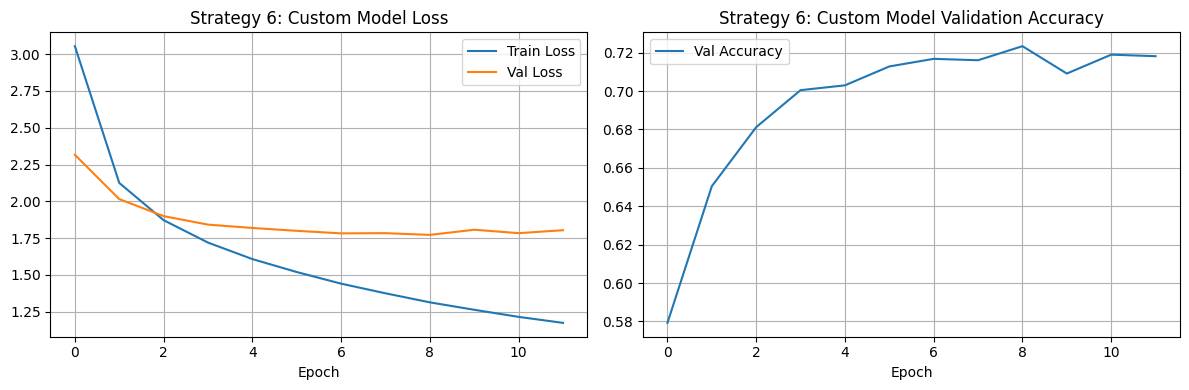

In [18]:
history_s6 = train_model(
    model_s6, aug_train_loader, val_loader, criterion_s6, optimizer_s6, device,
    epochs=30, patience=3, save_path="best_s6_custom.pth",
)

with open("history_s6_custom.json", "w") as f:
    json.dump(history_s6, f)

model_s6.load_state_dict(torch.load("best_s6_custom.pth", map_location=device))
test_metrics_s6 = evaluate_metrics(model_s6, test_loader, criterion, device)
print(f"Test Loss: {test_metrics_s6['loss']:.4f} | Test Acc: {test_metrics_s6['acc']:.4f}")
plot_history(history_s6, "Strategy 6: Custom Model")

In [19]:
def rebuild_model(key, ckpt):
    m = resnet18(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, 101)
    if key == "s3":
        inject_adapters(m)
    elif key == "s4":
        for ln in ["layer1", "layer2", "layer3", "layer4"]:
            _inject_lora_conv(getattr(m, ln))
    m.load_state_dict(torch.load(ckpt, map_location=device))
    return m.to(device).eval()

eval_models = {
    "Linear Probing":   rebuild_model("s1", "best_s1_linear_probe.pth"),
    "BatchNorm Tuning": rebuild_model("s2", "best_s2_batchnorm.pth"),
    "Adapter Tuning":   rebuild_model("s3", "best_s3_adapter.pth"),
    "LoRA":             rebuild_model("s4", "best_s4_lora.pth"),
    "Full Fine-tuning": rebuild_model("s5", "best_s5_full_finetune.pth"),
    "Custom Model":     rebuild_model("s6", "best_s6_custom.pth"),
}
print("All models loaded for robustness evaluation.")

All models loaded for robustness evaluation.


## Analysis: FLOPs, Inference Speed & Bubble Plots

In [20]:
!pip install thop -q

from thop import profile as thop_profile

def compute_analysis(model, device, n_batches=10, batch_size=64):
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(device)
    with torch.no_grad():
        flops, _ = thop_profile(model, inputs=(dummy,), verbose=False)

    batch = torch.randn(batch_size, 3, 224, 224).to(device)
    with torch.no_grad():
        for _ in range(3):
            model(batch)
        if device.type == "cuda":
            torch.cuda.synchronize()
        start = time.time()
        for _ in range(n_batches):
            model(batch)
        if device.type == "cuda":
            torch.cuda.synchronize()
        infer_time = (time.time() - start) / n_batches

    return flops / 1e9, infer_time

analysis_results = {}
for name, m in eval_models.items():
    gflops, infer_time = compute_analysis(m, device)
    analysis_results[name] = {"flops": gflops, "infer_time": infer_time}
    print(f"{name:<22} | GFLOPs: {gflops:.2f} | Infer time: {infer_time:.4f}s")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Linear Probing         | GFLOPs: 1.82 | Infer time: 0.0182s


BatchNorm Tuning       | GFLOPs: 1.82 | Infer time: 0.0177s


Adapter Tuning         | GFLOPs: 1.84 | Infer time: 0.0197s


LoRA                   | GFLOPs: 1.82 | Infer time: 0.0309s


Full Fine-tuning       | GFLOPs: 1.82 | Infer time: 0.0177s


Custom Model           | GFLOPs: 1.82 | Infer time: 0.0178s


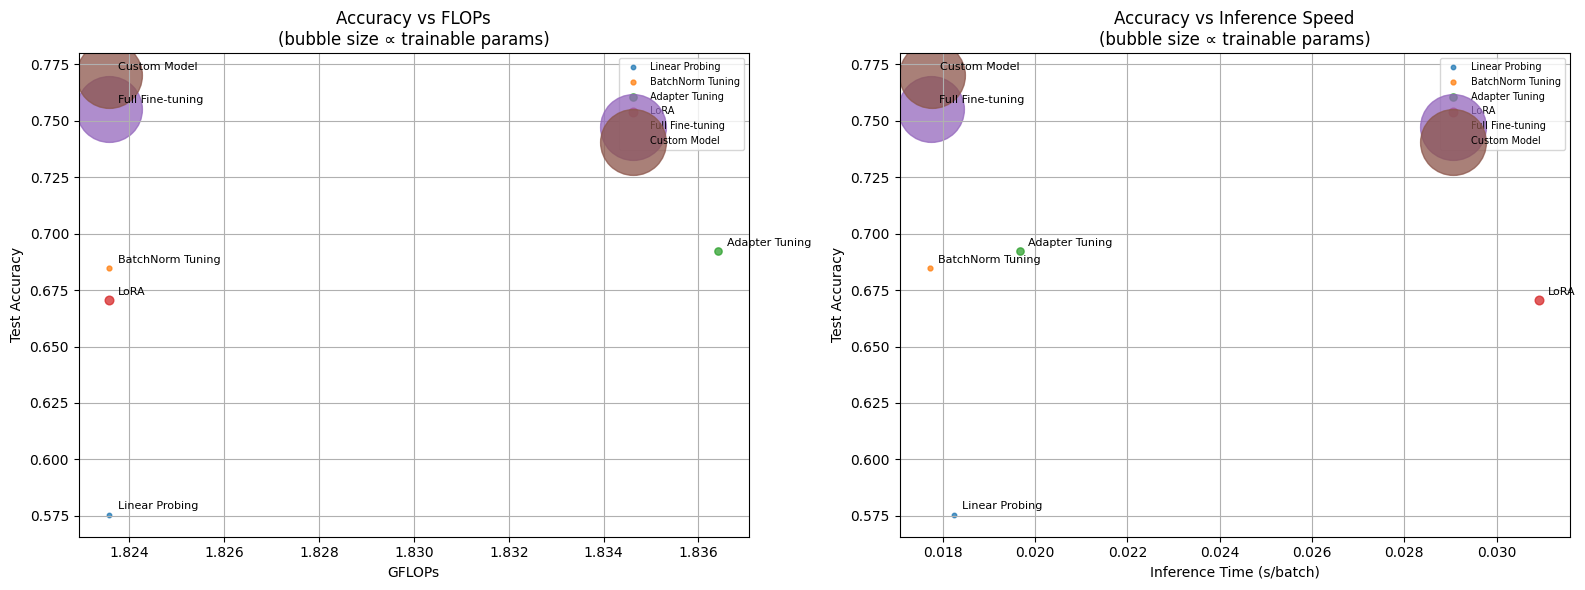

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

strategy_names = ["Linear Probing", "BatchNorm Tuning", "Adapter Tuning",
                   "LoRA", "Full Fine-tuning", "Custom Model"]
histories   = [history_s1, history_s2, history_s3, history_s4, history_s5, history_s6]
test_accs   = [test_metrics_s1["acc"], test_metrics_s2["acc"], test_metrics_s3["acc"],
               test_metrics_s4["acc"], test_metrics_s5["acc"], test_metrics_s6["acc"]]
param_counts = [h["trainable_params"] for h in histories]
bubble_sizes = [p / 5e3 for p in param_counts]
flops_vals   = [analysis_results[n]["flops"]     for n in strategy_names]
infer_vals   = [analysis_results[n]["infer_time"] for n in strategy_names]
colors = plt.cm.tab10(range(len(strategy_names)))

for ax, (x_vals, x_label, title) in zip(axes, [
    (flops_vals, "GFLOPs",                  "Accuracy vs FLOPs"),
    (infer_vals, "Inference Time (s/batch)", "Accuracy vs Inference Speed"),
]):
    for i, name in enumerate(strategy_names):
        ax.scatter(x_vals[i], test_accs[i], s=bubble_sizes[i], color=colors[i], alpha=0.75, label=name)
        ax.annotate(name, (x_vals[i], test_accs[i]), textcoords="offset points", xytext=(6, 4), fontsize=8)
    ax.set_xlabel(x_label)
    ax.set_ylabel("Test Accuracy")
    ax.set_title(f"{title}\n(bubble size ∝ trainable params)")
    ax.legend(fontsize=7)
    ax.grid(True)

plt.tight_layout()
plt.savefig("bubble_plots.png", dpi=150)
plt.show()

## Grad-CAM Explainability


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


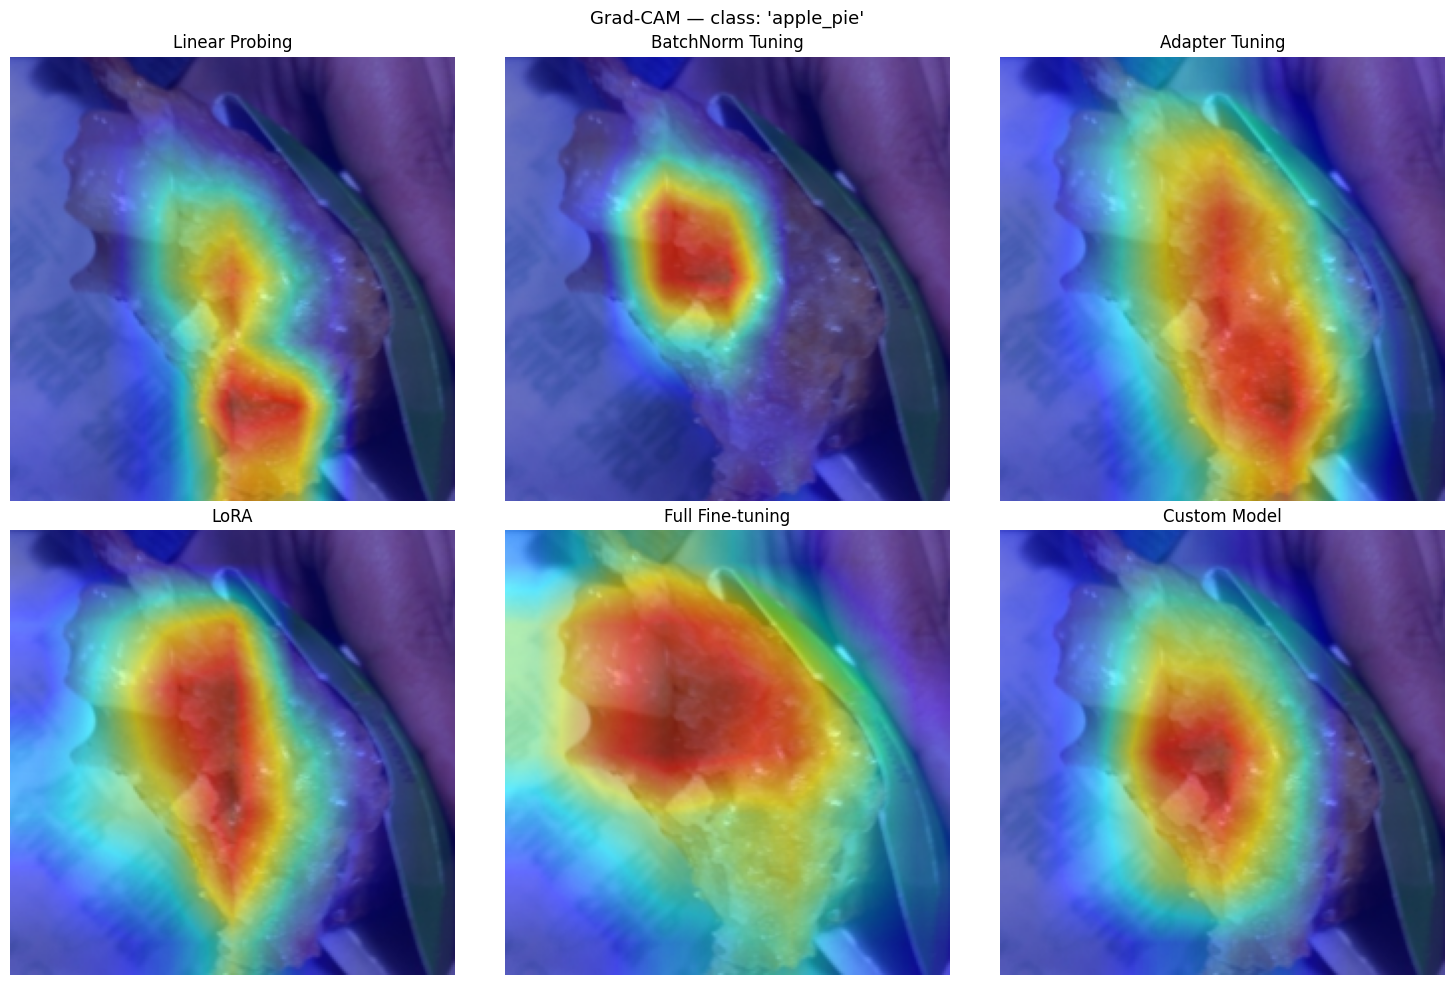

In [22]:
!pip install grad-cam -q

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import numpy as np

def gradcam_image(model, img_tensor, label, target_layer):
    cam = GradCAM(model=model, target_layers=[target_layer])
    grayscale = cam(
        input_tensor=img_tensor.unsqueeze(0).to(device),
        targets=[ClassifierOutputTarget(label)],
    )[0]
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])
    img_vis = (img_tensor.cpu() * std[:, None, None] + mean[:, None, None]).permute(1, 2, 0).numpy().clip(0, 1)
    return show_cam_on_image(img_vis, grayscale, use_rgb=True)

sample_img, sample_label = test_dataset[0]

cam_configs = {
    "Linear Probing":   ("s1", "best_s1_linear_probe.pth"),
    "BatchNorm Tuning": ("s2", "best_s2_batchnorm.pth"),
    "Adapter Tuning":   ("s3", "best_s3_adapter.pth"),
    "LoRA":             ("s4", "best_s4_lora.pth"),
    "Full Fine-tuning": ("s5", "best_s5_full_finetune.pth"),
    "Custom Model":     ("s6", "best_s6_custom.pth"),
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, (name, (key, ckpt)) in zip(axes.flatten(), cam_configs.items()):
    m = resnet18(weights=weights)
    m.fc = nn.Linear(m.fc.in_features, 101)
    if key == "s3":
        inject_adapters(m)
    elif key == "s4":
        for ln in ["layer1", "layer2", "layer3", "layer4"]:
            _inject_lora_conv(getattr(m, ln))
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m = m.to(device).eval()
    ax.imshow(gradcam_image(m, sample_img, sample_label, m.layer4[-1]))
    ax.set_title(name)
    ax.axis("off")

plt.suptitle(f"Grad-CAM — class: '{test_dataset.classes[sample_label]}'", fontsize=13)
plt.tight_layout()
plt.savefig("gradcam_comparison.png", dpi=150)
plt.show()